## Ejercicio 2.

Implemente el método de clustering k-medias sobre el conjunto de
datos Iris (GTP2) y compare las soluciones obtenidas con las de un SOM.
Para esto obtenga las matrices de contingencia entre ambos métodos y entre
cada método y las clases de referencia.

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics.cluster import contingency_matrix

tabla = pd.read_csv('../../Data/gtp_2/iris81_trn.csv', header=None).to_numpy()

X = tabla[:,0:4]

valores = [5, 20, 70]
centroides = X[valores,:]
centroides = (centroides.T).copy()

idx_X = np.zeros((X.shape[0],))
idx_X_anterior = -np.ones((X.shape[0],))

while (idx_X != idx_X_anterior).any():

    idx_X_anterior = idx_X.copy()

    for n in range(X.shape[0]):

        dist = np.zeros((centroides.shape[1],))

        for j in range(centroides.shape[1]):
            dist[j] = np.linalg.norm((X[n,:] - centroides[:,j]))

        idx_X[n] = np.argmin(dist)

    for idx in range(centroides.shape[1]):
        sumador = np.zeros((centroides.shape[0]))
        contador = 0
        for n in range(X.shape[0]):
            if idx == idx_X[n]:
                sumador += X[n,:]
                contador += 1

        centroides[:,idx] = sumador/contador 
    
    print(f'\n{centroides}')




[[5.18363636 6.0952381  6.50285714]
 [3.25818182 3.         2.96285714]
 [1.89636364 4.46666667 5.60571429]
 [0.44727273 1.41904762 1.95714286]]

[[5.11777778 5.8675     6.75769231]
 [3.46888889 2.765      3.04615385]
 [1.44222222 4.455      5.81538462]
 [0.26666667 1.4775     1.99230769]]

[[5.11777778 5.87619048 6.81666667]
 [3.46888889 2.75952381 3.07916667]
 [1.44222222 4.48333333 5.87916667]
 [0.26666667 1.50952381 1.97916667]]

[[5.11777778 5.87619048 6.81666667]
 [3.46888889 2.75952381 3.07916667]
 [1.44222222 4.48333333 5.87916667]
 [0.26666667 1.50952381 1.97916667]]


In [3]:
W = np.random.random((5, 5, X.shape[1])) - 0.5 

epoca = 1
epoca_max = 1000

Areas = [5, 4, 3, 2, 1]
Betas = [0.8, 0.6,  0.5, 0.3, 0.1] 

y_som = -np.ones((X.shape[0],))

while epoca < epoca_max:

    if epoca < 200:
        A_n = Areas[0]
        beta_n = Betas[0]
        tasa_actual = 0.8
    elif 200 <= epoca < 400:
        A_n = Areas[1]
        beta_n = Betas[1]
        tasa_actual = 0.6
    elif 400 <= epoca < 600:
        A_n = Areas[2]
        beta_n = Betas[2]
        tasa_actual = 0.4
    elif 600 <= epoca < 800:
        A_n = Areas[3]
        beta_n = Betas[3]
        tasa_actual = 0.2
    elif 800 <= epoca < epoca_max:
        A_n = Areas[4] 
        beta_n = Betas[4]
        tasa_actual = 0.1


    for n in range(X.shape[0]):

        # buscar neurona ganadora 
        distancias = np.linalg.norm(X[n] - W, axis=2) # la dimension 2 de W son los vectores de pesos, del mismo tamaño que cada patrón de entrada
        j_ganador = np.unravel_index(np.argmin(distancias), distancias.shape) # Ej: (3, 4)

        for i in range(W.shape[0]):
            for z in range(W.shape[1]):
                
                # ver la distancia de las otras neuronas a la ganadora
                neurona_i = np.array([i, z])
                neurona_ganadora = np.array(j_ganador)

                d = np.linalg.norm(neurona_i - neurona_ganadora)

                # actualizar los pesos
                if d == 0: # era la neurona ganadora
                    W[i, z] += tasa_actual * (X[n] - W[i, z])
                
                elif d <= A_n: # actualizar si era del area vecina
                    W[i, z] += tasa_actual * beta_n * (X[n] - W[i, z])

    epoca += 1

for n in range(X.shape[0]):

    # buscar neurona ganadora 
    distancias = np.linalg.norm(X[n] - W, axis=2) # la dimension 2 de W son los vectores de pesos, del mismo tamaño que cada patrón de entrada
    j_ganador = np.unravel_index(np.argmin(distancias), distancias.shape) # Ej: (3, 4)

    y_som[n] = j_ganador[0] * 5 + j_ganador[1]

In [4]:
matriz_contingencia_metodos = contingency_matrix(idx_X, y_som)
print(f'Matriz de contingencia K-medias y SOM:\n{matriz_contingencia_metodos}')

y_d = np.zeros((X.shape[0],))

for n in range(X.shape[0]):

    salida_n = tabla[n, 4:]

    if salida_n[1] == 1:
        y_d[n] = 1
    elif salida_n[2] == 1:
        y_d[n] = 2


matriz_cont_y_kmedia = contingency_matrix(y_d, idx_X)
matriz_cont_y_som = contingency_matrix(y_d, y_som)

print(f'\nMatriz de contingencia y_referencia y K-medias:\n{matriz_cont_y_kmedia}')
print(f'\nMatriz de contingencia y_referencia y SOM:\n{matriz_cont_y_som}')

Matriz de contingencia K-medias y SOM:
[[ 0  0  0  0  0  0  0  5  0  0  4  8  0  0 11  9  0  0  0  8]
 [ 1  7  1  9  8  2  6  0  0  2  0  0  0  0  0  0  0  0  6  0]
 [ 0  0  0  0  0  0  0  0  6  0  0  0  7  2  0  0  6  3  0  0]]

Matriz de contingencia y_referencia y K-medias:
[[ 0 10 24]
 [ 0 32  0]
 [45  0  0]]

Matriz de contingencia y_referencia y SOM:
[[ 1  0  0  0  8  0  0  0  6  1  0  0  7  2  0  0  6  3  0  0]
 [ 0  7  1  9  0  2  6  0  0  1  0  0  0  0  0  0  0  0  6  0]
 [ 0  0  0  0  0  0  0  5  0  0  4  8  0  0 11  9  0  0  0  8]]


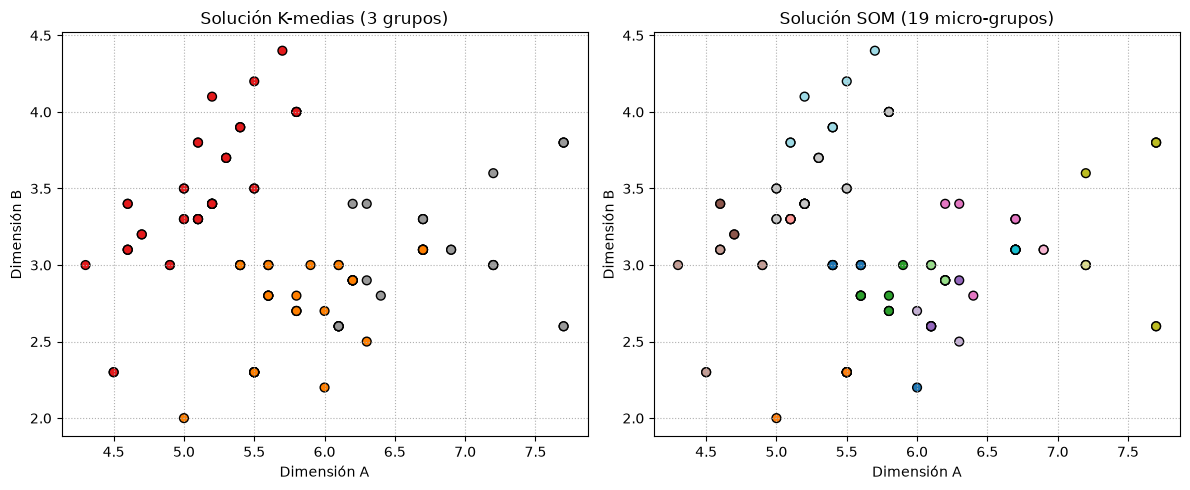

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

dim1 = X[:, 0]
dim2 = X[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(dim1, dim2, c=idx_X, cmap='Set1', edgecolor='k', s=40)
ax1.grid(True, linestyle=':')
ax1.set_title('Solución K-medias (3 grupos)')
ax1.set_xlabel('Dimensión A')
ax1.set_ylabel('Dimensión B')

ax2.scatter(dim1, dim2, c=y_som, cmap='tab20', edgecolor='k', s=40)
ax2.grid(True, linestyle=':')
ax2.set_title('Solución SOM (19 micro-grupos)')
ax2.set_xlabel('Dimensión A')
ax2.set_ylabel('Dimensión B')

plt.tight_layout()
plt.show()

Grafique las neuronas del SOM en 2D con una escala de colores según las frecuencias de activación para los datos de Iris. Indique además cuál es la clase de Iris que cada neurona

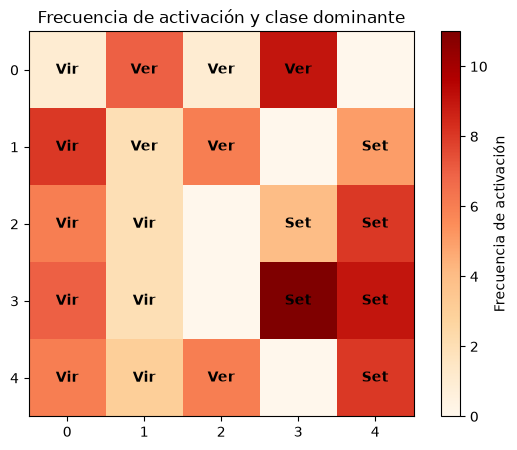

In [6]:

cont_act_neur = np.zeros([5,5])
cont_tipo_neur = np.zeros((5,5,3))

for n in range(X.shape[0]):
    distancias = np.linalg.norm(X[n] - W, axis=2) # la dimension 2 de W son los vectores de pesos, del mismo tamaño que cada patrón de entrada
    j_ganador = np.unravel_index(np.argmin(distancias), distancias.shape)
    f , c = j_ganador

    cont_act_neur[f,c] += 1
    if y_d[n] == 0:
        cont_tipo_neur[f,c,0] += 1
    elif y_d[n] == 1:
        cont_tipo_neur[f,c,1] += 1
    else:
        cont_tipo_neur[f,c,2] += 1

nombres_clases = {0: 'Vir', 1: 'Ver', 2: 'Set'} 

fig, ax = plt.subplots(figsize=(7, 5))
cax = ax.imshow(cont_act_neur, cmap='OrRd')
plt.colorbar(cax, label='Frecuencia de activación')

for f in range(5):
    for c in range(5):
        if cont_act_neur[f, c] > 0:
            clase_ganadora = np.argmax(cont_tipo_neur[f, c])
            texto_a_mostrar = nombres_clases[clase_ganadora]
            ax.text(c, f, texto_a_mostrar, ha='center', va='center', color='black', fontweight='bold')

ax.set_title("Frecuencia de activación y clase dominante")
ax.set_xticks(range(5))
ax.set_yticks(range(5))
plt.show()